In [3]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report

In [4]:
original_data_path = '/kaggle/input/datasets/adilmubashirchaudhry/plant-village-dataset/PlantVillageDataset/PlantVillage'
data_path = '/kaggle/working/PlantVillage_clean'

if not os.path.exists(data_path):
    shutil.copytree(original_data_path, data_path)

bad_folder = os.path.join(data_path, 'PlantVillage')
if os.path.exists(bad_folder):
    shutil.rmtree(bad_folder)
    print("Removed bad nested folder")

print("Final classes:")
for item in sorted(os.listdir(data_path)):
    full_path = os.path.join(data_path, item)
    if os.path.isdir(full_path):
        print(item, "-", len(os.listdir(full_path)), "items")

Removed bad nested folder
Final classes:
Pepper__bell___Bacterial_spot - 997 items
Pepper__bell___healthy - 1478 items
Potato___Early_blight - 1000 items
Potato___Late_blight - 1000 items
Potato___healthy - 152 items
Tomato_Bacterial_spot - 2127 items
Tomato_Early_blight - 1000 items
Tomato_Late_blight - 1909 items
Tomato_Leaf_Mold - 952 items
Tomato_Septoria_leaf_spot - 1771 items
Tomato_Spider_mites_Two_spotted_spider_mite - 1676 items
Tomato__Target_Spot - 1404 items
Tomato__Tomato_YellowLeaf__Curl_Virus - 3209 items
Tomato__Tomato_mosaic_virus - 373 items
Tomato_healthy - 1591 items


In [5]:
original_data_path = '/kaggle/input/datasets/adilmubashirchaudhry/plant-village-dataset/PlantVillageDataset/PlantVillage'
data_path = '/kaggle/working/PlantVillage_clean'

# Force fresh copy - remove any partial/old copy first
if os.path.exists(data_path):
    shutil.rmtree(data_path)
    print("Removed old/partial copy")

shutil.copytree(original_data_path, data_path)
print("Fresh copy completed")

bad_folder = os.path.join(data_path, 'PlantVillage')
if os.path.exists(bad_folder):
    shutil.rmtree(bad_folder)
    print("Removed bad nested folder")

print("Final classes:")
class_count = 0
for item in sorted(os.listdir(data_path)):
    full_path = os.path.join(data_path, item)
    if os.path.isdir(full_path):
        print(item, "-", len(os.listdir(full_path)), "items")
        class_count += 1
print(f"\nTotal classes: {class_count}")

Removed old/partial copy
Fresh copy completed
Removed bad nested folder
Final classes:
Pepper__bell___Bacterial_spot - 997 items
Pepper__bell___healthy - 1478 items
Potato___Early_blight - 1000 items
Potato___Late_blight - 1000 items
Potato___healthy - 152 items
Tomato_Bacterial_spot - 2127 items
Tomato_Early_blight - 1000 items
Tomato_Late_blight - 1909 items
Tomato_Leaf_Mold - 952 items
Tomato_Septoria_leaf_spot - 1771 items
Tomato_Spider_mites_Two_spotted_spider_mite - 1676 items
Tomato__Target_Spot - 1404 items
Tomato__Tomato_YellowLeaf__Curl_Virus - 3209 items
Tomato__Tomato_mosaic_virus - 373 items
Tomato_healthy - 1591 items

Total classes: 15


In [6]:
datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

train_data = datagen.flow_from_directory(
    data_path,
    target_size=(128, 128),
    batch_size=32,
    subset='training',
    class_mode='categorical',
    shuffle=True,
    seed=42
)

val_data = datagen.flow_from_directory(
    data_path,
    target_size=(128, 128),
    batch_size=32,
    subset='validation',
    class_mode='categorical',
    shuffle=False,
    seed=42
)

print("Classes found:", train_data.num_classes)
print("Train class_indices:", train_data.class_indices)
print("Val class_indices:", val_data.class_indices)
assert train_data.class_indices == val_data.class_indices, "Class index mismatch!"

Found 16516 images belonging to 15 classes.
Found 4122 images belonging to 15 classes.
Classes found: 15
Train class_indices: {'Pepper__bell___Bacterial_spot': 0, 'Pepper__bell___healthy': 1, 'Potato___Early_blight': 2, 'Potato___Late_blight': 3, 'Potato___healthy': 4, 'Tomato_Bacterial_spot': 5, 'Tomato_Early_blight': 6, 'Tomato_Late_blight': 7, 'Tomato_Leaf_Mold': 8, 'Tomato_Septoria_leaf_spot': 9, 'Tomato_Spider_mites_Two_spotted_spider_mite': 10, 'Tomato__Target_Spot': 11, 'Tomato__Tomato_YellowLeaf__Curl_Virus': 12, 'Tomato__Tomato_mosaic_virus': 13, 'Tomato_healthy': 14}
Val class_indices: {'Pepper__bell___Bacterial_spot': 0, 'Pepper__bell___healthy': 1, 'Potato___Early_blight': 2, 'Potato___Late_blight': 3, 'Potato___healthy': 4, 'Tomato_Bacterial_spot': 5, 'Tomato_Early_blight': 6, 'Tomato_Late_blight': 7, 'Tomato_Leaf_Mold': 8, 'Tomato_Septoria_leaf_spot': 9, 'Tomato_Spider_mites_Two_spotted_spider_mite': 10, 'Tomato__Target_Spot': 11, 'Tomato__Tomato_YellowLeaf__Curl_Virus': 

In [7]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_data.classes),
    y=train_data.classes
)
class_weight_dict = dict(enumerate(class_weights))
print(class_weight_dict)

{0: np.float64(1.379782790309106), 1: np.float64(0.9307410538179769), 2: np.float64(1.3763333333333334), 3: np.float64(1.3763333333333334), 4: np.float64(9.025136612021859), 5: np.float64(0.6469251860556209), 6: np.float64(1.3763333333333334), 7: np.float64(0.7205933682373473), 8: np.float64(1.4449693788276465), 9: np.float64(0.7770406963067513), 10: np.float64(0.8210787969177231), 11: np.float64(0.9795966785290628), 12: np.float64(0.4289313076223867), 13: np.float64(3.6824972129319957), 14: np.float64(0.8649384655669023)}


In [8]:
base_model = MobileNetV2(input_shape=(128,128,3), include_top=False, weights='imagenet')
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    layers.Dropout(0.4),
    layers.Dense(train_data.num_classes, activation='softmax')
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

2026-06-26 10:28:48.405865: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,887 (9.25 MB)

 Trainable params: 165,903 (648.06 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [10]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)
]

In [11]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=callbacks,
    class_weight=class_weight_dict
)

Epoch 1/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 208s 391ms/step - accuracy: 0.6638 - loss: 1.2424 - val_accuracy: 0.8316 - val_loss: 0.6958 - learning_rate: 0.0010
Epoch 2/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 199s 385ms/step - accuracy: 0.7979 - loss: 0.7781 - val_accuracy: 0.8358 - val_loss: 0.6666 - learning_rate: 0.0010
Epoch 3/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 200s 386ms/step - accuracy: 0.8093 - loss: 0.7247 - val_accuracy: 0.8702 - val_loss: 0.5297 - learning_rate: 0.0010
Epoch 4/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 196s 380ms/step - accuracy: 0.8228 - loss: 0.6836 - val_accuracy: 0.8799 - val_loss: 0.5184 - learning_rate: 0.0010
Epoch 5/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 201s 388ms/step - accuracy: 0.8282 - loss: 0.6639 - val_accuracy: 0.8666 - val_loss: 0.5405 - learning_rate: 0.0010
Epoch 6/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 199s 385ms/step - accuracy: 0.8413 - loss: 0.6340 - val_accuracy: 0.8770 - val_loss: 0.5265 - learning_rate: 0.0010
Epoch 7/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 194s 375ms/step - accura

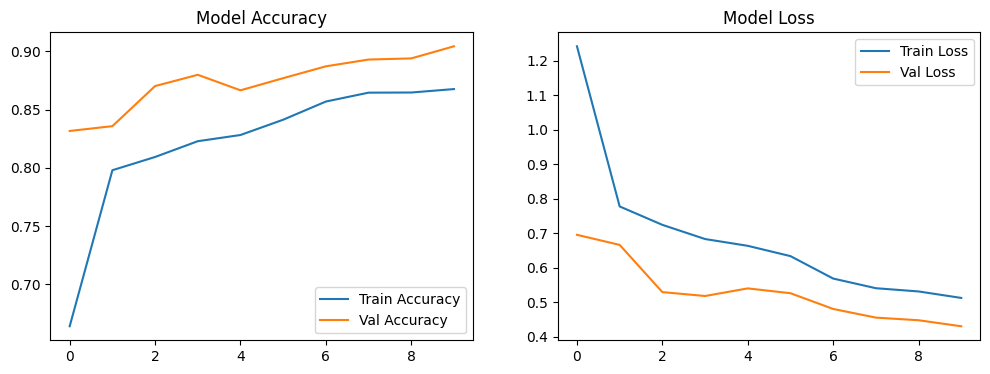

In [12]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.legend()
plt.show()

In [13]:
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00002),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_finetune = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=callbacks,
    class_weight=class_weight_dict
)

Epoch 1/15
517/517 ━━━━━━━━━━━━━━━━━━━━ 238s 442ms/step - accuracy: 0.7782 - loss: 0.7892 - val_accuracy: 0.8588 - val_loss: 0.5531 - learning_rate: 2.0000e-05
Epoch 2/15
517/517 ━━━━━━━━━━━━━━━━━━━━ 229s 443ms/step - accuracy: 0.8510 - loss: 0.5688 - val_accuracy: 0.8782 - val_loss: 0.4830 - learning_rate: 2.0000e-05
Epoch 3/15
517/517 ━━━━━━━━━━━━━━━━━━━━ 227s 439ms/step - accuracy: 0.8713 - loss: 0.5081 - val_accuracy: 0.9117 - val_loss: 0.4033 - learning_rate: 1.0000e-05
Epoch 4/15
517/517 ━━━━━━━━━━━━━━━━━━━━ 225s 435ms/step - accuracy: 0.8807 - loss: 0.4816 - val_accuracy: 0.9170 - val_loss: 0.3652 - learning_rate: 1.0000e-05
Epoch 5/15
517/517 ━━━━━━━━━━━━━━━━━━━━ 221s 427ms/step - accuracy: 0.8845 - loss: 0.4543 - val_accuracy: 0.9221 - val_loss: 0.3635 - learning_rate: 1.0000e-05
Epoch 6/15
517/517 ━━━━━━━━━━━━━━━━━━━━ 224s 433ms/step - accuracy: 0.8955 - loss: 0.4325 - val_accuracy: 0.9284 - val_loss: 0.3456 - learning_rate: 1.0000e-05
Epoch 7/15
517/517 ━━━━━━━━━━━━━━━━━━━━ 

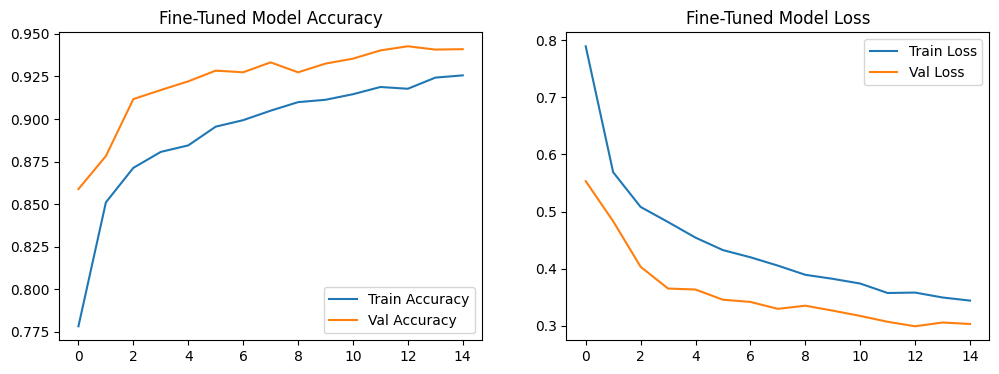

Model saved!


In [14]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history_finetune.history['accuracy'], label='Train Accuracy')
plt.plot(history_finetune.history['val_accuracy'], label='Val Accuracy')
plt.title('Fine-Tuned Model Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_finetune.history['loss'], label='Train Loss')
plt.plot(history_finetune.history['val_loss'], label='Val Loss')
plt.title('Fine-Tuned Model Loss')
plt.legend()
plt.show()

model.save('plant_disease_model.keras')
print("Model saved!")

In [15]:
val_data.reset()
preds = model.predict(val_data, steps=len(val_data))
y_pred = np.argmax(preds, axis=1)
y_true = val_data.classes

print(classification_report(y_true, y_pred, target_names=list(val_data.class_indices.keys())))

129/129 ━━━━━━━━━━━━━━━━━━━━ 40s 302ms/step
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.98      0.98      0.98       199
                     Pepper__bell___healthy       0.99      0.98      0.99       295
                      Potato___Early_blight       0.98      0.96      0.97       200
                       Potato___Late_blight       0.95      0.97      0.96       200
                           Potato___healthy       0.88      1.00      0.94        30
                      Tomato_Bacterial_spot       0.95      0.96      0.95       425
                        Tomato_Early_blight       0.85      0.81      0.83       200
                         Tomato_Late_blight       0.95      0.93      0.94       381
                           Tomato_Leaf_Mold       0.87      0.96      0.91       190
                  Tomato_Septoria_leaf_spot       0.95      0.89      0.92       354
Tomato_Spider_mites_

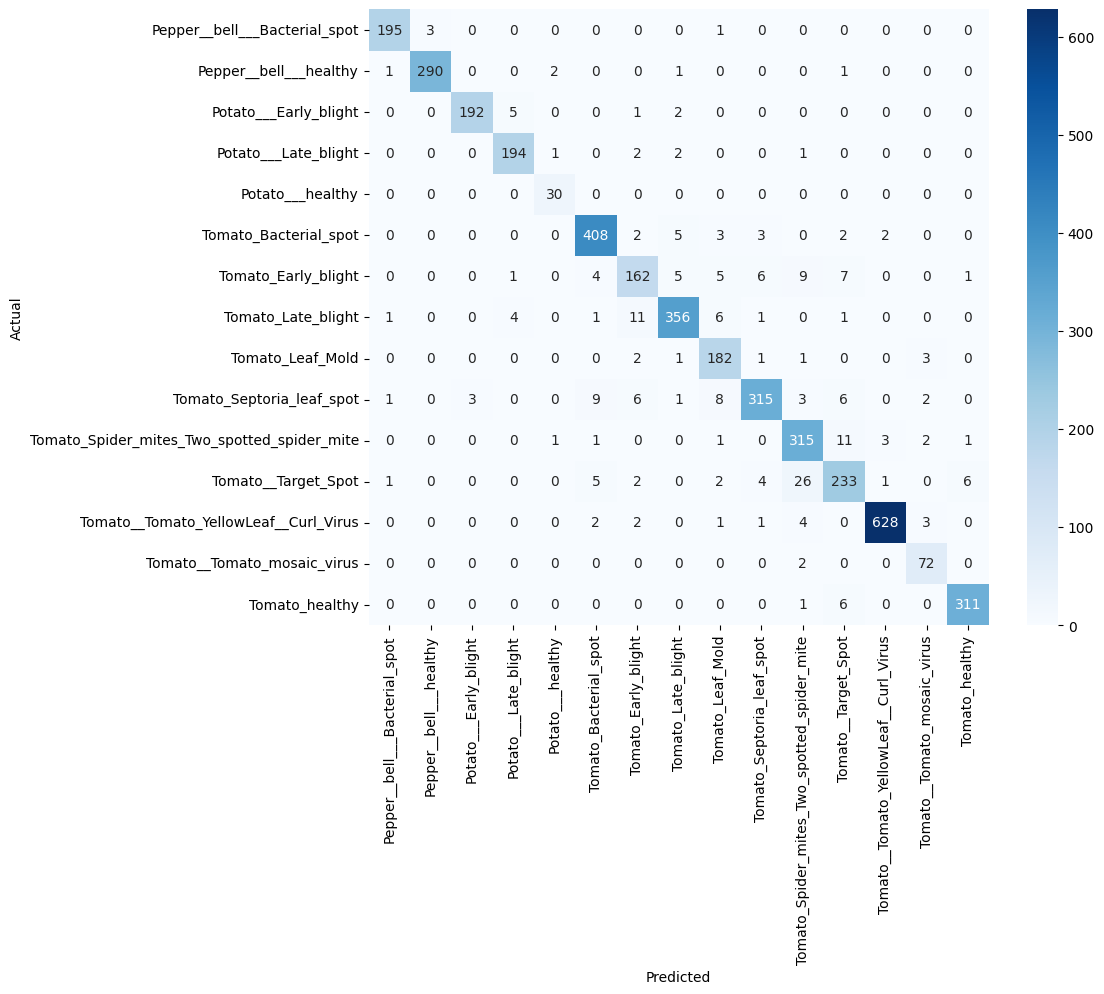

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(val_data.class_indices.keys()),
            yticklabels=list(val_data.class_indices.keys()))
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [18]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

def predict_image(img_path, model, class_indices):
    idx_to_class = {v: k for k, v in class_indices.items()}

    img = image.load_img(img_path, target_size=(128, 128))
    img_array = image.img_to_array(img)
    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    preds = model.predict(img_array)
    predicted_idx = np.argmax(preds[0])
    confidence = preds[0][predicted_idx] * 100

    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Predicted: {idx_to_class[predicted_idx]}\nConfidence: {confidence:.2f}%")
    plt.show()

    top3_idx = np.argsort(preds[0])[-3:][::-1]
    print("Top 3 predictions:")
    for idx in top3_idx:
        print(f"  {idx_to_class[idx]}: {preds[0][idx]*100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


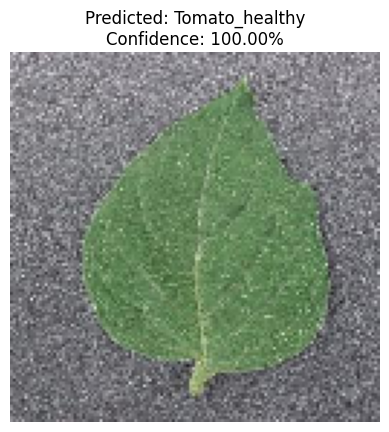

Top 3 predictions:
  Tomato_healthy: 100.00%
  Tomato__Target_Spot: 0.00%
  Tomato_Late_blight: 0.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


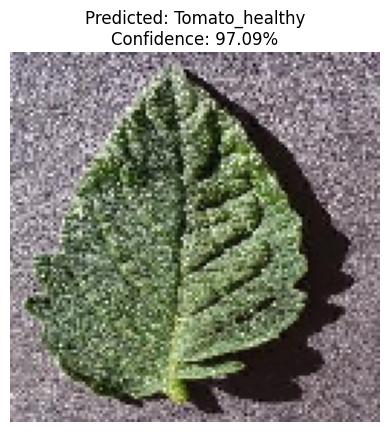

Top 3 predictions:
  Tomato_healthy: 97.09%
  Tomato_Spider_mites_Two_spotted_spider_mite: 2.55%
  Tomato__Target_Spot: 0.32%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


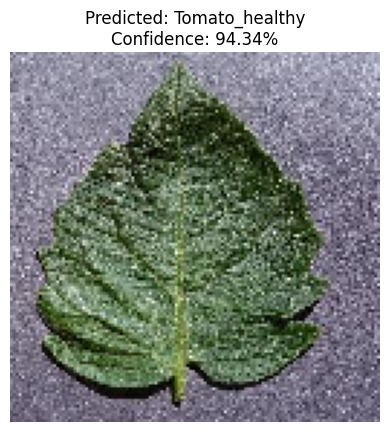

Top 3 predictions:
  Tomato_healthy: 94.34%
  Tomato__Target_Spot: 5.15%
  Tomato_Spider_mites_Two_spotted_spider_mite: 0.50%


In [19]:
#Tomato healthy
data_path = '/kaggle/working/PlantVillage_clean'
sample_class = 'Tomato_healthy'

class_folder = os.path.join(data_path, sample_class)
sample_files = os.listdir(class_folder)[:3]

for f in sample_files:
    img_path = os.path.join(class_folder, f)
    predict_image(img_path, model, train_data.class_indices)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


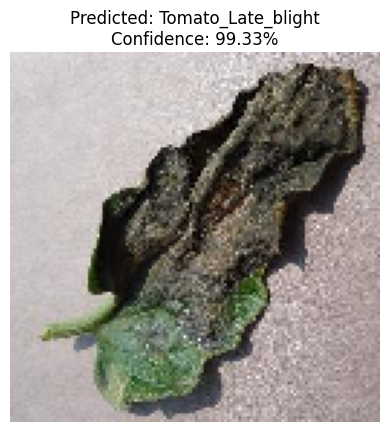

Top 3 predictions:
  Tomato_Late_blight: 99.33%
  Tomato_Early_blight: 0.22%
  Potato___Late_blight: 0.19%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


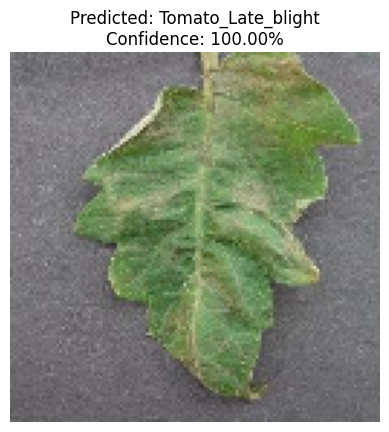

Top 3 predictions:
  Tomato_Late_blight: 100.00%
  Tomato_Bacterial_spot: 0.00%
  Tomato_healthy: 0.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


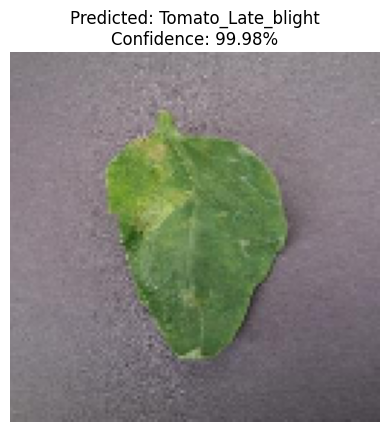

Top 3 predictions:
  Tomato_Late_blight: 99.98%
  Tomato_healthy: 0.02%
  Tomato_Septoria_leaf_spot: 0.00%


In [20]:
#Tomato Late Blight
sample_class = 'Tomato_Late_blight'

class_folder = os.path.join(data_path, sample_class)
sample_files = os.listdir(class_folder)[:3]

for f in sample_files:
    img_path = os.path.join(class_folder, f)
    predict_image(img_path, model, train_data.class_indices)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


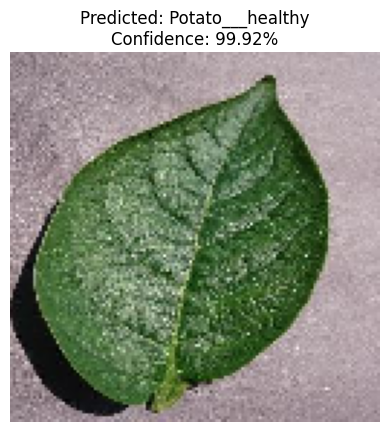

Top 3 predictions:
  Potato___healthy: 99.92%
  Potato___Late_blight: 0.04%
  Pepper__bell___healthy: 0.03%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


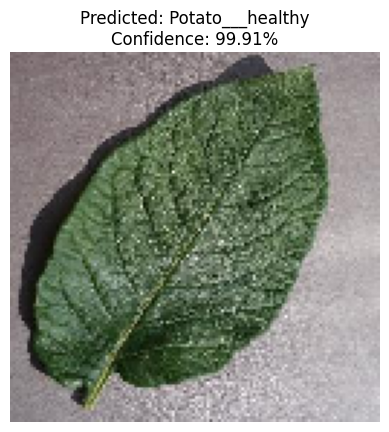

Top 3 predictions:
  Potato___healthy: 99.91%
  Potato___Late_blight: 0.08%
  Tomato__Target_Spot: 0.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


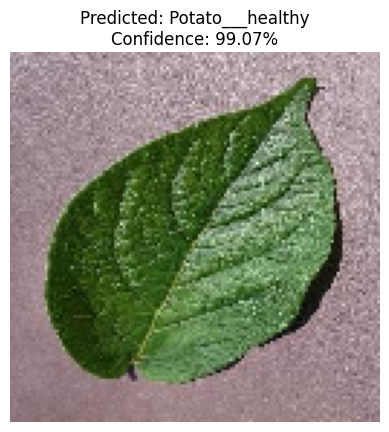

Top 3 predictions:
  Potato___healthy: 99.07%
  Potato___Late_blight: 0.47%
  Pepper__bell___healthy: 0.31%


In [21]:
#Potato Healthy
sample_class = 'Potato___healthy'

class_folder = os.path.join(data_path, sample_class)
sample_files = os.listdir(class_folder)[:3]

for f in sample_files:
    img_path = os.path.join(class_folder, f)
    predict_image(img_path, model, train_data.class_indices)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


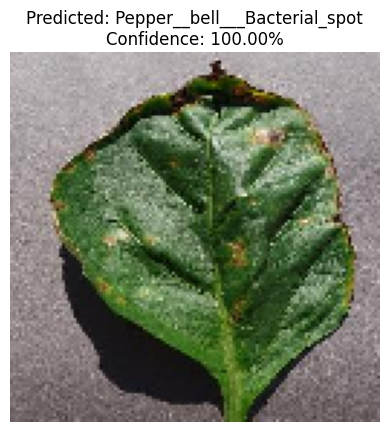

Top 3 predictions:
  Pepper__bell___Bacterial_spot: 100.00%
  Pepper__bell___healthy: 0.00%
  Tomato_Early_blight: 0.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


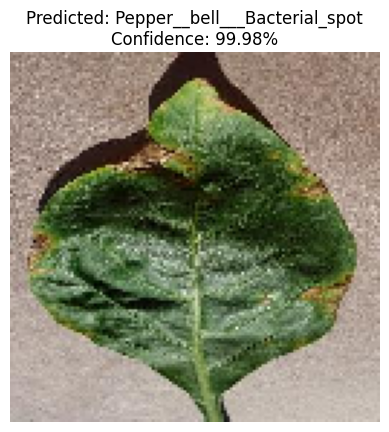

Top 3 predictions:
  Pepper__bell___Bacterial_spot: 99.98%
  Pepper__bell___healthy: 0.02%
  Tomato_Spider_mites_Two_spotted_spider_mite: 0.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


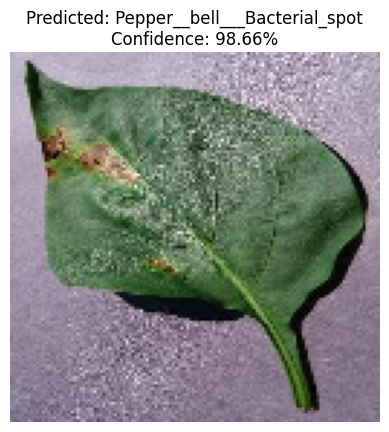

Top 3 predictions:
  Pepper__bell___Bacterial_spot: 98.66%
  Pepper__bell___healthy: 1.33%
  Tomato_Early_blight: 0.00%


In [22]:
#Pepper Bell Bacterial
sample_class = 'Pepper__bell___Bacterial_spot'

class_folder = os.path.join(data_path, sample_class)
sample_files = os.listdir(class_folder)[:3]

for f in sample_files:
    img_path = os.path.join(class_folder, f)
    predict_image(img_path, model, train_data.class_indices)

In [23]:
val_loss, val_accuracy = model.evaluate(val_data)
print(f"Final Validation Accuracy: {val_accuracy*100:.2f}%")
print(f"Final Validation Loss: {val_loss:.4f}")

129/129 ━━━━━━━━━━━━━━━━━━━━ 40s 310ms/step - accuracy: 0.9401 - loss: 0.3055
Final Validation Accuracy: 94.01%
Final Validation Loss: 0.3055
